# Exploratory Data Analysis for Preprocessed Electricity Demand Data
This notebook loads `preprocessed_data.csv`, validates the cleaning, visualizes temporal seasonality, examines weather and economic relationships, and inspects autocorrelation to justify lag-based forecasting features.

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)

file_path = 'preprocessed_data.csv'
df = pd.read_csv(file_path, parse_dates=['datetime'])
print('Dataset shape:', df.shape)
print('\nData types:')
print(df.dtypes)
print('\nSample data:')
print(df.head())

Dataset shape: (88932, 30)

Data types:
datetime                                                              datetime64[us]
generation_mw                                                                float64
demand_mw                                                                    float64
load_shedding                                                                float64
gas                                                                          float64
liquid_fuel                                                                  float64
coal                                                                         float64
hydro                                                                        float64
solar                                                                        float64
wind                                                                         float64
india_bheramara_hvdc                                                         float64
india_tripura            

In [4]:
print('\nInfo:')
df.info(show_counts=True)

print('\nDescriptive statistics:')
print(df.describe().T)

missing = df.isna().mean().sort_values(ascending=False)

if missing.max() > 0:
    plt.figure(figsize=(12, 8))
    sns.barplot(x=missing.values * 100, y=missing.index, palette='viridis')
    plt.xlabel('Percent Missing')
    plt.title('Missing Values by Column')
    plt.xlim(0, missing.max() * 100 * 1.05)
    plt.tight_layout()
    plt.show()
else:
    print('No missing values found in the dataset.')


Info:
<class 'pandas.DataFrame'>
RangeIndex: 88932 entries, 0 to 88931
Data columns (total 30 columns):
 #   Column                                                              Non-Null Count  Dtype         
---  ------                                                              --------------  -----         
 0   datetime                                                            88932 non-null  datetime64[us]
 1   generation_mw                                                       88932 non-null  float64       
 2   demand_mw                                                           88932 non-null  float64       
 3   load_shedding                                                       88932 non-null  float64       
 4   gas                                                                 88932 non-null  float64       
 5   liquid_fuel                                                         88932 non-null  float64       
 6   coal                                                      

C:\Users\Daksh\AppData\Local\Temp\ipykernel_39708\4177523361.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='hour', y='demand_mw', data=df, ax=axes[0], palette='Blues')
C:\Users\Daksh\AppData\Local\Temp\ipykernel_39708\4177523361.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='dayofweek', y='demand_mw', data=df, ax=axes[1], palette='Greens')
C:\Users\Daksh\AppData\Local\Temp\ipykernel_39708\4177523361.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='month', y='demand_mw', data=df, ax=axes[2], palette='Oranges')


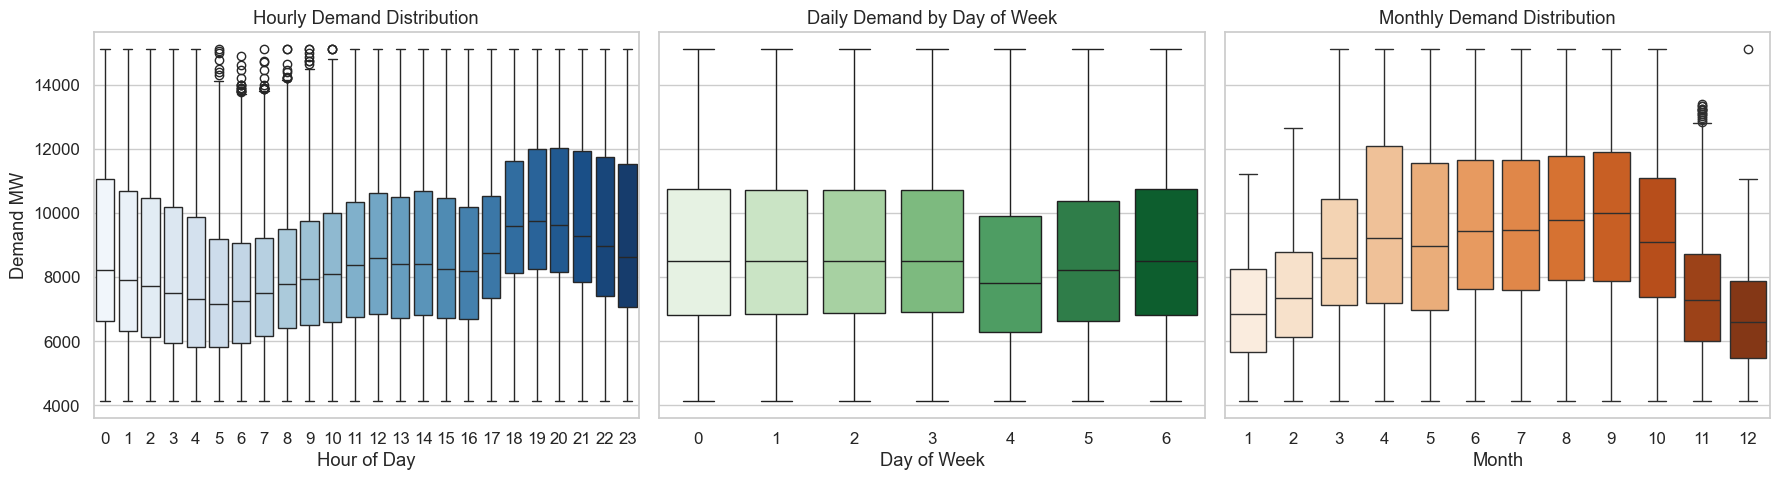

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)

# Distribution of demand by hour of day
sns.boxplot(x='hour', y='demand_mw', data=df, ax=axes[0], palette='Blues')
axes[0].set_title('Hourly Demand Distribution')
axes[0].set_xlabel('Hour of Day')
axes[0].set_ylabel('Demand MW')

# Demand variation across days of the week
sns.boxplot(x='dayofweek', y='demand_mw', data=df, ax=axes[1], palette='Greens')
axes[1].set_title('Daily Demand by Day of Week')
axes[1].set_xlabel('Day of Week')
axes[1].set_ylabel('')

# Monthly demand distribution and seasonality
sns.boxplot(x='month', y='demand_mw', data=df, ax=axes[2], palette='Oranges')
axes[2].set_title('Monthly Demand Distribution')
axes[2].set_xlabel('Month')
axes[2].set_ylabel('')

plt.tight_layout()
plt.show()

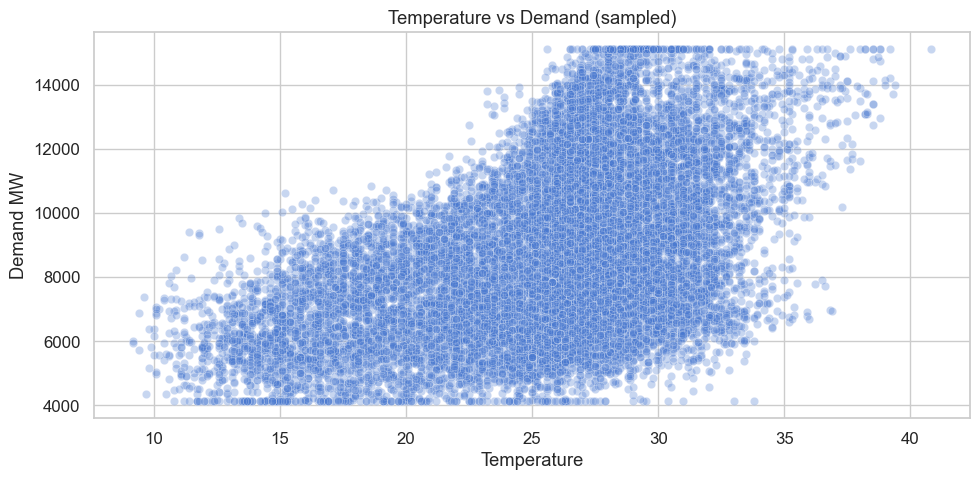

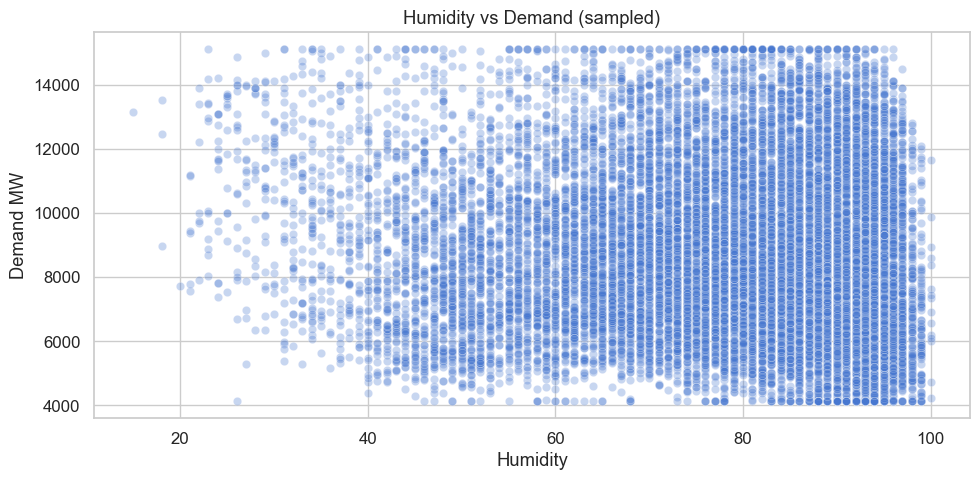

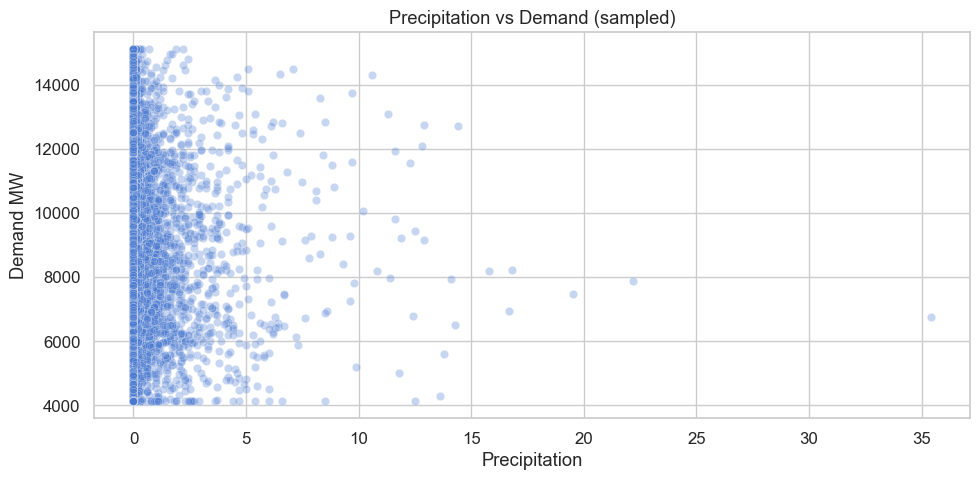

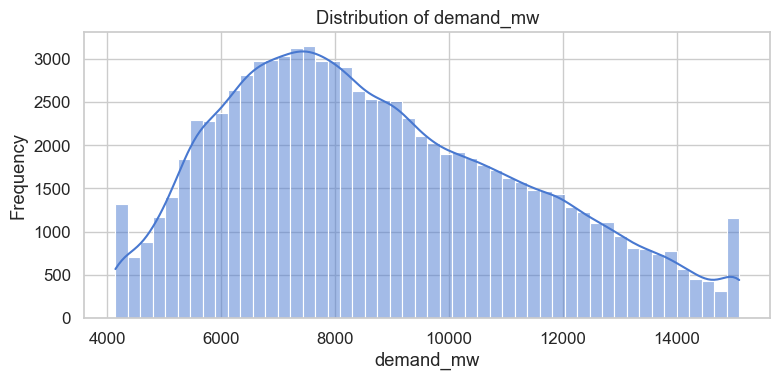

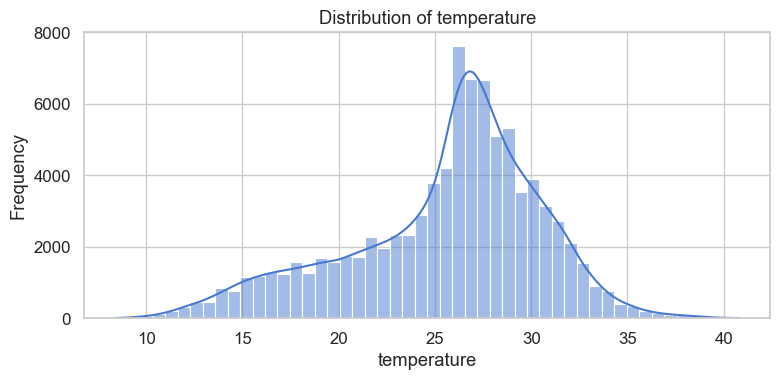

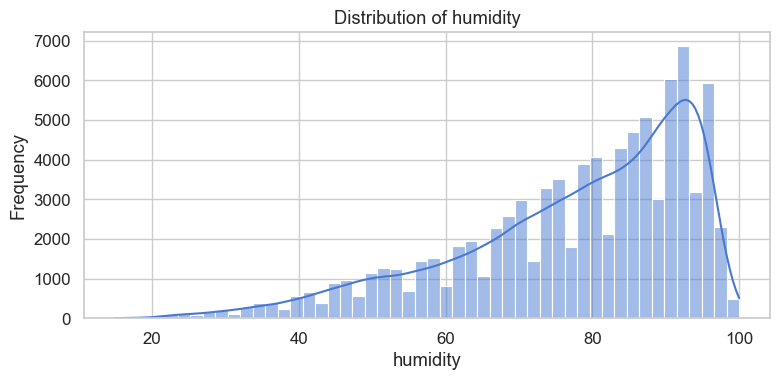

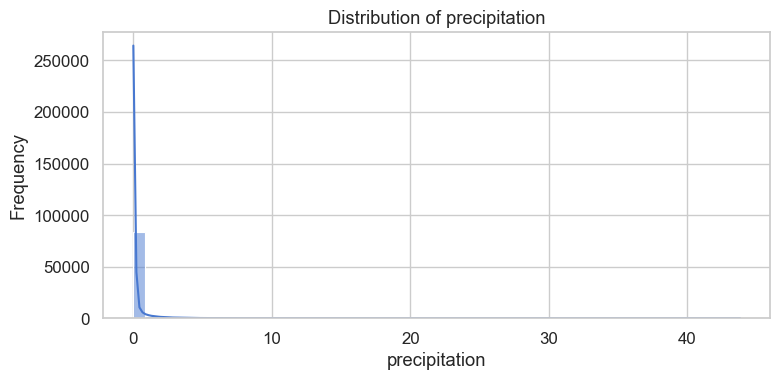

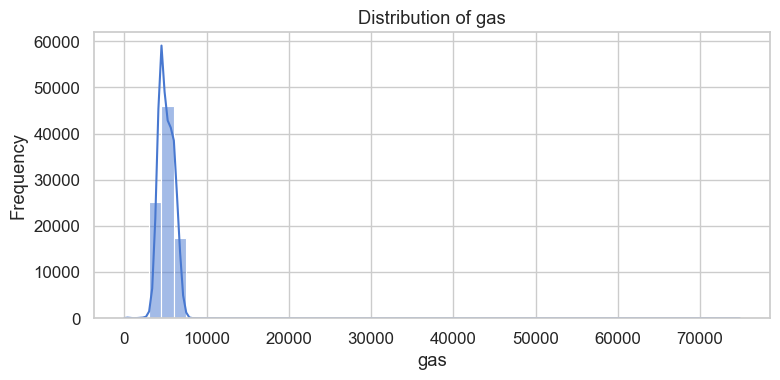

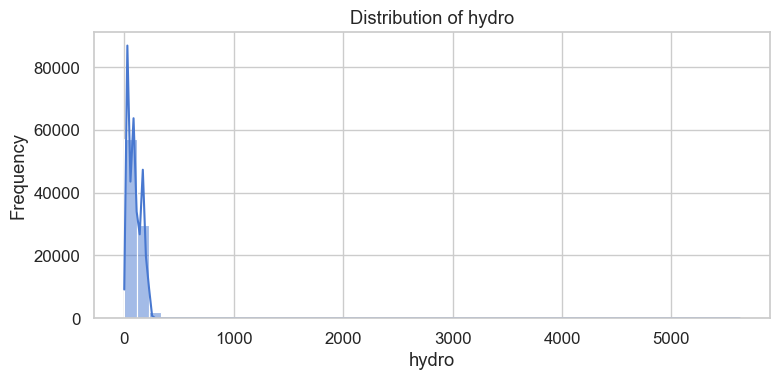

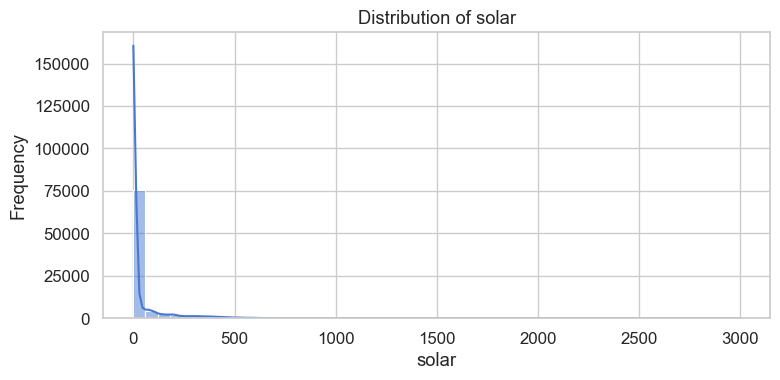

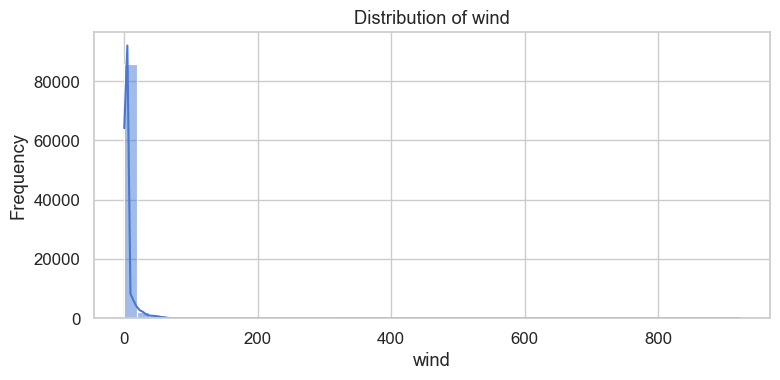

In [6]:
for feature in ['temperature', 'humidity', 'precipitation']:
    plt.figure(figsize=(10, 5))
    sns.scatterplot(x=feature, y='demand_mw', data=df.sample(frac=0.2, random_state=42), alpha=0.3)
    plt.title(f'{feature.capitalize()} vs Demand (sampled)')
    plt.xlabel(feature.capitalize())
    plt.ylabel('Demand MW')
    plt.tight_layout()
    plt.show()

# Distributions of key features
key_features = ['demand_mw', 'temperature', 'humidity', 'precipitation', 'gas', 'hydro', 'solar', 'wind']
for feat in key_features:
    plt.figure(figsize=(8, 4))
    sns.histplot(df[feat].dropna(), kde=True, bins=50)
    plt.title(f'Distribution of {feat}')
    plt.xlabel(feat)
    plt.ylabel('Frequency')
    plt.tight_layout()
    plt.show()

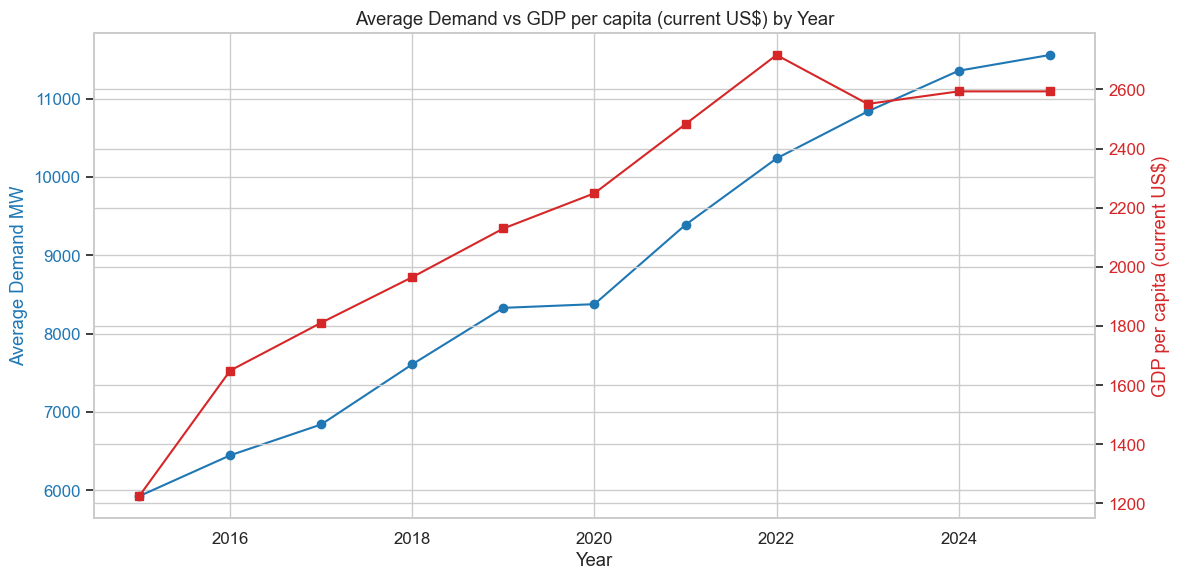

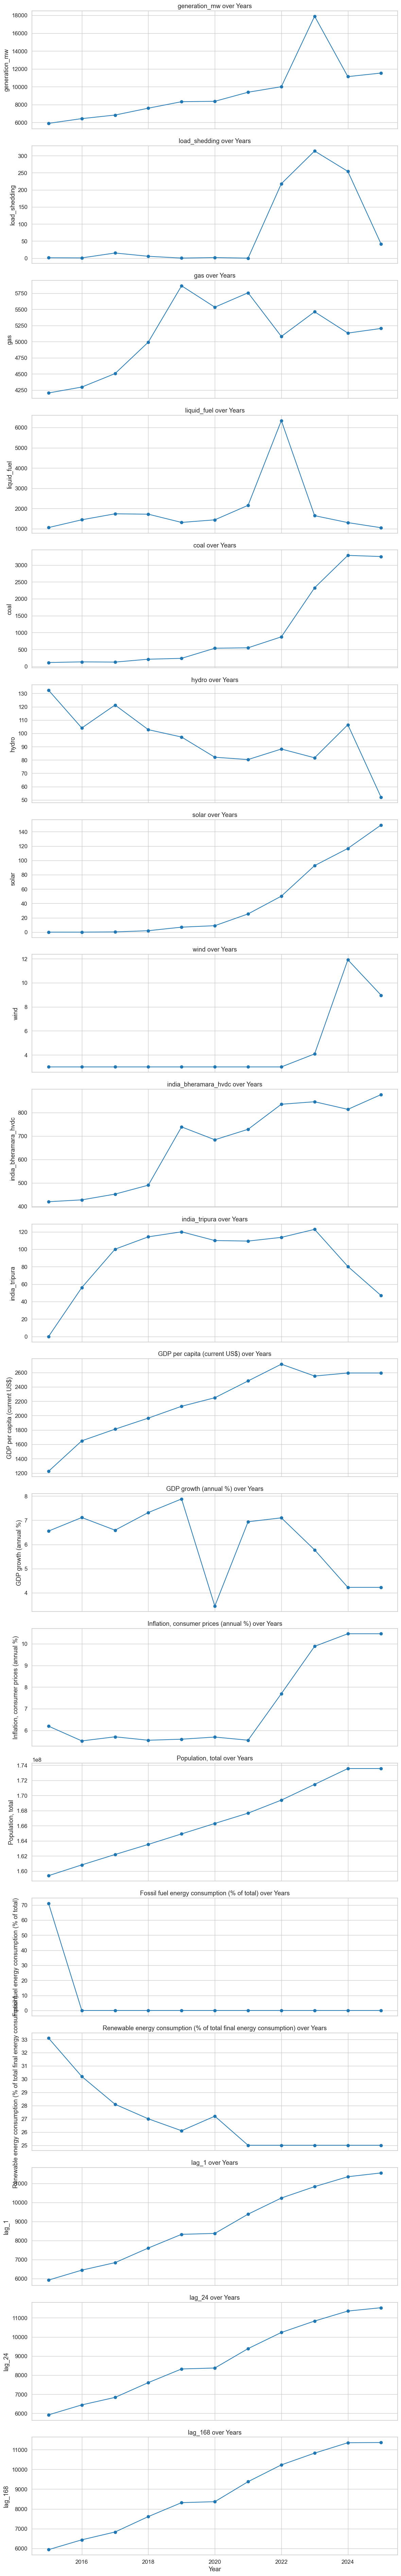

In [ ]:
exclude_list = ['datetime', 'Year', 'hour', 'dayofweek', 'month', 'day', 'demand_mw', 'next_hour_demand_mw', 'temperature', 'humidity', 'precipitation']
candidate_indicators = []
for c in df.columns:
    if c not in exclude_list and df[c].dtype.kind in 'fi':
        candidate_indicators.append(c)

indicator_col = None
for c in candidate_indicators:
    if any(term in c.lower() for term in ['gdp', 'gni', 'income', 'gross']):
        indicator_col = c
        break

if indicator_col is None and candidate_indicators:
    indicator_col = candidate_indicators[0]

if indicator_col is not None:
    yearly = df.groupby('Year').agg({'demand_mw': 'mean', indicator_col: 'mean'}).reset_index()
    fig, ax1 = plt.subplots(figsize=(12, 6))
    ax1.plot(yearly['Year'], yearly['demand_mw'], marker='o', color='tab:blue', label='Average Demand')
    ax1.set_xlabel('Year')
    ax1.set_ylabel('Average Demand MW', color='tab:blue')
    ax1.tick_params(axis='y', labelcolor='tab:blue')

    ax2 = ax1.twinx()
    ax2.plot(yearly['Year'], yearly[indicator_col], marker='s', color='tab:red', label=indicator_col)
    ax2.set_ylabel(indicator_col, color='tab:red')
    ax2.tick_params(axis='y', labelcolor='tab:red')

    plt.title(f'Average Demand vs {indicator_col} by Year')
    fig.tight_layout()
    plt.show()
else:
    print('No economic indicator column found for the dual-axis plot.')

# Trends of economic indicators over years
if candidate_indicators:
    n_ind = len(candidate_indicators)
    fig, axes = plt.subplots(n_ind, 1, figsize=(12, 4 * n_ind), sharex=True)
    if n_ind == 1:
        axes = [axes]
    for i, ind in enumerate(candidate_indicators):
        yearly_ind = df.groupby('Year')[ind].mean()
        axes[i].plot(yearly_ind.index, yearly_ind.values, marker='o', color='tab:blue')
        axes[i].set_title(f'{ind} over Years')
        axes[i].set_ylabel(ind)
    axes[-1].set_xlabel('Year')
    plt.tight_layout()
    plt.show()

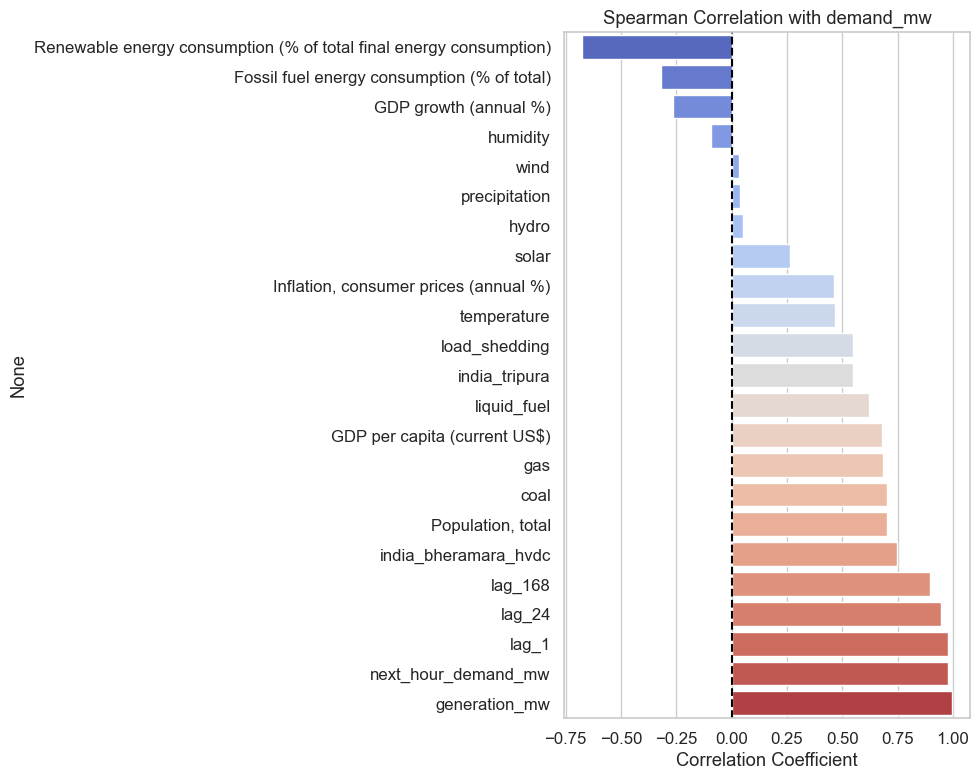

In [ ]:
correlation_features = ['next_hour_demand_mw', 'temperature', 'humidity', 'precipitation', 'gas', 'liquid_fuel', 'coal', 'hydro', 'solar', 'wind']

temp_features = []
for c in correlation_features:
    if c in df.columns:
        temp_features.append(c)
correlation_features = temp_features

for c in candidate_indicators:
    if c not in correlation_features:
        correlation_features.append(c)

target = 'demand_mw'
if target in correlation_features:
    correlation_features.remove(target)
corrs = df[correlation_features + [target]].corr(method='spearman')[target].drop(target).sort_values()

plt.figure(figsize=(10, 8))
sns.barplot(x=corrs.values, y=corrs.index, hue=corrs.index, palette='coolwarm', legend=False)
plt.title(f'Spearman Correlation with {target}')
plt.xlabel('Correlation Coefficient')
plt.axvline(x=0, color='black', linestyle='--')
plt.tight_layout()
plt.show()

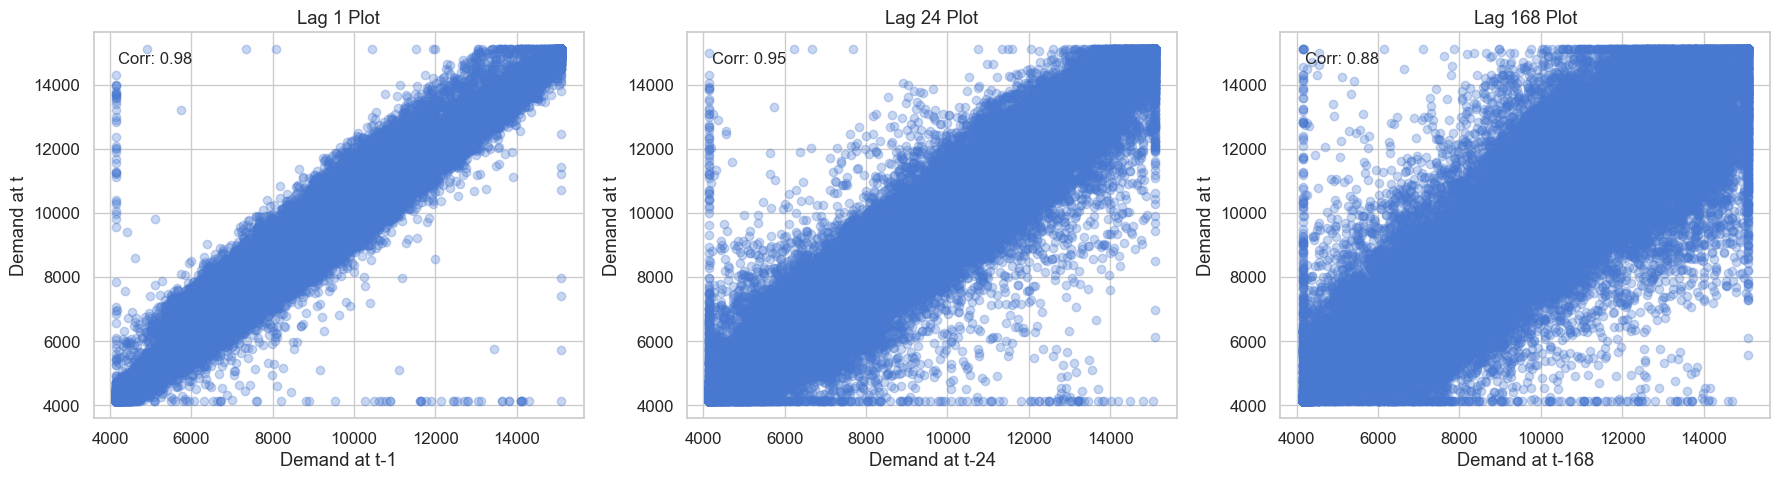

In [ ]:
series = df['demand_mw'].dropna()

lags_to_plot = [1, 24, 168]
fig, axes = plt.subplots(1, len(lags_to_plot), figsize=(18, 5))
for i, lag in enumerate(lags_to_plot):
    lagged_series = series.shift(lag).dropna()
    current_series = series.iloc[lag:].reset_index(drop=True)
    axes[i].scatter(lagged_series, current_series, alpha=0.3)
    axes[i].set_title(f'Lag {lag} Plot')
    axes[i].set_xlabel(f'Demand at t-{lag}')
    axes[i].set_ylabel('Demand at t')
    # Add correlation line
    corr = np.corrcoef(lagged_series, current_series)[0, 1]
    axes[i].text(0.05, 0.95, f'Corr: {corr:.2f}', transform=axes[i].transAxes, fontsize=12, verticalalignment='top')
plt.tight_layout()
plt.show()